Num GPUs Available:  1
GPU is available, using GPU for training.
Found 27011 images belonging to 2 classes.
Found 4766 images belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb2 (Functional)  (None, 7, 7, 1408)       7768569   
                                                                 
 global_average_pooling2d (G  (None, 1408)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               360704    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                             

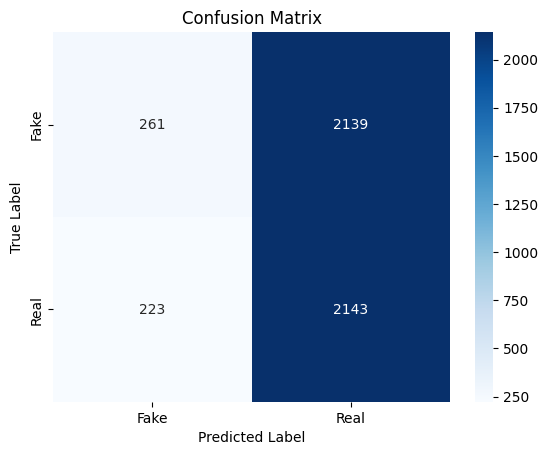

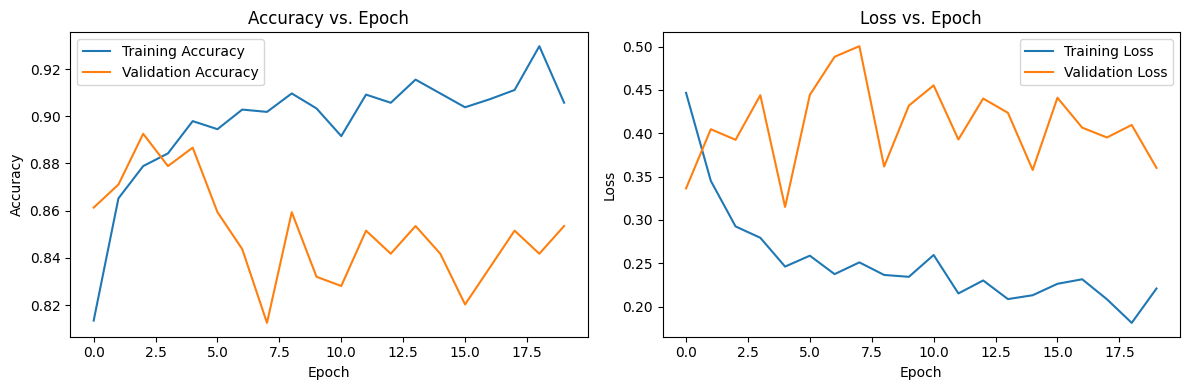

Found 8506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
532/532 [==============================] - 166s 310ms/step


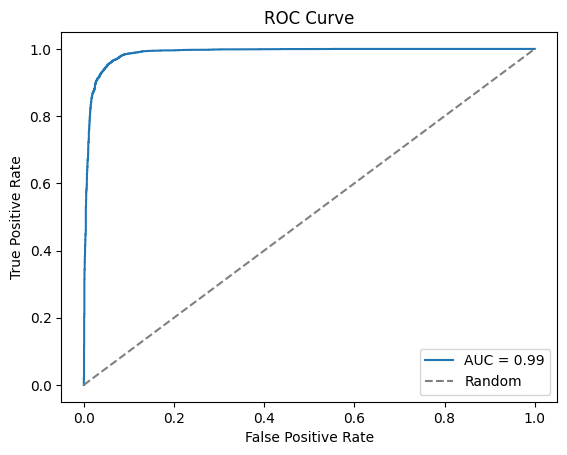

optimal threshold =  0.8898668
Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95      4037
        Real       0.95      0.95      0.95      4469

    accuracy                           0.95      8506
   macro avg       0.95      0.95      0.95      8506
weighted avg       0.95      0.95      0.95      8506

Confusion Matrix:
[[3825  212]
 [ 209 4260]]


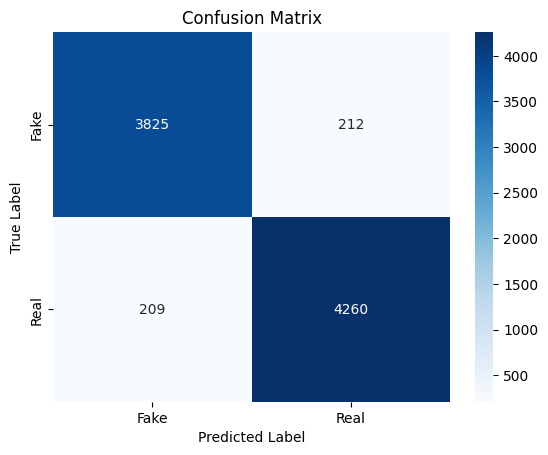

Evaluation Metrics:
accuracy: 0.9505055255114038
precision: 0.9481903817550819
recall: 0.947485756750062
f1_score: 0.9478379382976088
auc: 0.9879460259992696


In [2]:
import model_fit_evaluate
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_efficientnetb2
import tensorflow as tf
import os 
import telebot

if __name__ == '__main__':
    data_dir = '../balanced_data/train'
    image_size = (224, 224)
    batch_size = 4  
    epochs = 20

    train_generator, validation_generator = model_fit_evaluate.create_data_generators(data_dir, image_size, batch_size, preprocessing_function=preprocess_input_efficientnetb2)

    model = model_fit_evaluate.create_custom_model(
    base_model=EfficientNetB2, 
    weights="imagenet",
    input_shape=(224, 224, 3),
    num_classes=1, 
    trainable_base=False 
    )

    history = model_fit_evaluate.train_model(model, train_generator, validation_generator, epochs, batch_size, early_stopping_patience=7, reduce_lr_patience=4, reduce_lr_factor=0.2)

    model_fit_evaluate.evaluate_model(model, validation_generator)

    model_fit_evaluate.plot_training_history(history)
    
    test_data_dir = '../balanced_data/test'  

    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, test_data_dir, preprocess_input_efficientnetb2, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics[0].items():
        print(f"{metric}: {value}")


Found 10110 images belonging to 2 classes.
632/632 [==============================] - 485s 765ms/step
[[1]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.32      0.48      5089
        Fake       0.59      0.99      0.74      5021

    accuracy                           0.65     10110
   macro avg       0.78      0.66      0.61     10110
weighted avg       0.78      0.65      0.61     10110

Confusion Matrix:
[[1622 3467]
 [  42 4979]]


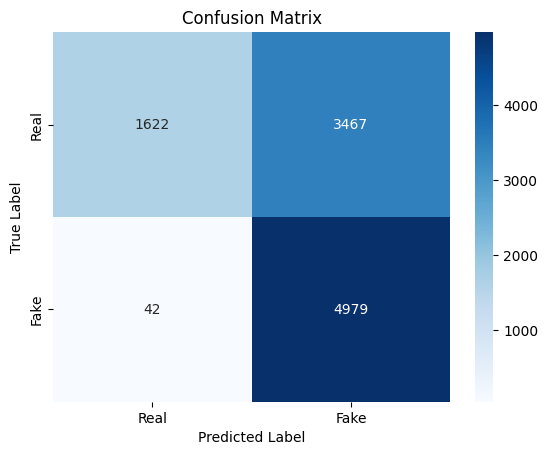

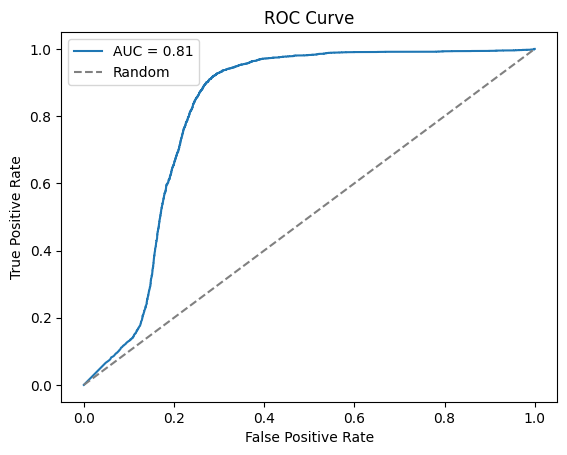

Evaluation Metrics:
accuracy: 0.6529179030662711
precision: 0.9747596153846154
recall: 0.3187266653566516
f1_score: 0.4803790907744706
auc: 0.8147258816957774


In [2]:
    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, '../balanced_data/test', preprocess_input_efficientnetb2, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

In [6]:
model.save_weights('EfficientNetB2_Deepfake.keras')